# Finetune Grader and Router

This notebook implements a paired fine-tuning workflow for the AI574 project:

1. Train a lightweight learned document grader to replace LLM-as-judge relevance scoring.
2. Train a lightweight learned domain router to reduce LLM supervisor calls.

The notebook is self-contained and is designed to be re-runnable with cached distilled datasets.

## 1) Setup and Environment

Run this section first. It installs training dependencies and loads project modules.

In [ ]:
# If running in Colab/Jupyter, uncomment when needed.
# %pip install -q sentence-transformers transformers datasets accelerate evaluate scikit-learn matplotlib seaborn

import os
import sys
import json
import time
import random
import shutil
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Any, Tuple

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Avoid interactive W&B prompts during notebook training.
os.environ.setdefault('WANDB_DISABLED', 'true')
os.environ.setdefault('WANDB_MODE', 'disabled')

PROJECT_ROOT = Path.cwd().resolve().parents[0] if (Path.cwd() / 'foundation').exists() else Path.cwd().resolve()
if not (PROJECT_ROOT / 'foundation').exists() and (PROJECT_ROOT / 'AI574' / 'foundation').exists():
    PROJECT_ROOT = PROJECT_ROOT / 'AI574'

sys.path.insert(0, str(PROJECT_ROOT))

from config.settings import CONFIG
from foundation.model_registry import get_llm
from foundation.embedding_service import EmbeddingService
from foundation.vector_store import VectorStoreService
from rag_core.document_grader import DocumentGrader
from orchestration.hybrid_router import LexicalDomainClassifier, HybridRoutePrediction
from orchestration.supervisor import SupervisorAgent

# Local fallbacks. Cell 3 remaps these to Google Drive when Drive is mounted.
LOCAL_DATA_DIR = PROJECT_ROOT / 'data' / 'finetune'
LOCAL_MODEL_DIR = PROJECT_ROOT / 'models'
DATA_DIR = LOCAL_DATA_DIR
MODEL_DIR = LOCAL_MODEL_DIR
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
# Set these to True only when you explicitly want to regenerate artifacts.
FORCE_REBUILD_DATA = False
FORCE_RETRAIN_GRADER = False
FORCE_RETRAIN_ROUTER = False


def _model_artifact_exists(path: Path) -> bool:
    return path.exists() and path.is_dir() and any(path.iterdir())


def _data_artifacts_exist(paths: List[Path]) -> bool:
    return all(path.exists() and path.stat().st_size > 0 for path in paths)


def _load_jsonl(path: Path) -> List[dict]:
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


random.seed(SEED)
np.random.seed(SEED)

print('Project root:', PROJECT_ROOT)
print('Initial local data dir:', DATA_DIR)
print('Initial local model dir:', MODEL_DIR)
print('Vector collections:', CONFIG.vector_store.collections)

Project root: /content/AI574
Initial local data dir: /content/AI574/data/finetune
Initial local model dir: /content/AI574/models
Vector collections: {'industrial': 'industrial_knowledge', 'recipe': 'recipe_knowledge', 'scientific': 'scientific_knowledge'}


In [ ]:
# Optional: mount Google Drive in Colab
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

print('Running in Colab:', IN_COLAB)

# Persist fine-tuning datasets and models in Google Drive when available.
DRIVE_ROOT = Path('/content/drive/MyDrive')
if DRIVE_ROOT.exists():
    ARTIFACT_ROOT = DRIVE_ROOT / 'AI574' / 'finetune_artifacts'
    DRIVE_DATA_DIR = ARTIFACT_ROOT / 'data' / 'finetune'
    DRIVE_MODEL_DIR = ARTIFACT_ROOT / 'models'
    DRIVE_DATA_DIR.mkdir(parents=True, exist_ok=True)
    DRIVE_MODEL_DIR.mkdir(parents=True, exist_ok=True)

    # One-time migration: preserve any local outputs already created in this runtime.
    def _copy_missing_tree(src: Path, dst: Path) -> None:
        if not src.exists():
            return
        for item in src.iterdir():
            target = dst / item.name
            if target.exists():
                continue
            if item.is_dir():
                shutil.copytree(item, target)
            else:
                shutil.copy2(item, target)

    _copy_missing_tree(LOCAL_DATA_DIR, DRIVE_DATA_DIR)
    _copy_missing_tree(LOCAL_MODEL_DIR, DRIVE_MODEL_DIR)

    DATA_DIR = DRIVE_DATA_DIR
    MODEL_DIR = DRIVE_MODEL_DIR
    print('Using persistent Drive artifact root:', ARTIFACT_ROOT)
else:
    DATA_DIR = LOCAL_DATA_DIR
    MODEL_DIR = LOCAL_MODEL_DIR
    print('Google Drive not available; using local ephemeral artifact paths.')

print('Persistent DATA_DIR:', DATA_DIR)
print('Persistent MODEL_DIR:', MODEL_DIR)

# Load credentials using the same pattern as Multi_Domain_Agent.ipynb
import getpass

def _try_userdata(name: str) -> None:
    if os.environ.get(name):
        return
    try:
        from google.colab import userdata  # type: ignore
        val = userdata.get(name)
        if val:
            os.environ[name] = val
    except Exception:
        pass

for _secret in ("GOOGLE_API_KEY", "KAGGLE_API_TOKEN", "KAGGLE_USERNAME", "KAGGLE_KEY", "GROQ_API_KEY"):
    _try_userdata(_secret)

if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter GOOGLE_API_KEY: ")

print("GOOGLE_API_KEY loaded:", bool(os.environ.get("GOOGLE_API_KEY")))
print("GROQ_API_KEY loaded:", bool(os.environ.get("GROQ_API_KEY")))

# Initialize LLM for distillation (graceful fallback if key/network is unavailable).
llm = None
try:
    llm = get_llm('gemini_flash')
    print('LLM initialized for distillation and silver labeling.')
except Exception as e:
    print('Warning: could not initialize gemini_flash:', e)
    print('Notebook will continue. Distillation cells can use cached JSONL files if present.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Colab: True
Using persistent Drive artifact root: /content/drive/MyDrive/AI574/finetune_artifacts
Persistent DATA_DIR: /content/drive/MyDrive/AI574/finetune_artifacts/data/finetune
Persistent MODEL_DIR: /content/drive/MyDrive/AI574/finetune_artifacts/models
GOOGLE_API_KEY loaded: True
GROQ_API_KEY loaded: False
LLM initialized for distillation and silver labeling.


## 2) Data Synthesis - Grader

This section distills a silver relevance dataset for the learned document grader.

Output files:
- `data/finetune/grader_train.jsonl`
- `data/finetune/grader_val.jsonl`
- `data/finetune/grader_gold.jsonl`

In [ ]:
from langchain_core.documents import Document

embedder = EmbeddingService()
vs = VectorStoreService(embedding_service=embedder)

def _sample_docs_by_domain(vs: VectorStoreService, per_domain: int = 300) -> Dict[str, List[Document]]:
    sampled = {}
    for domain in CONFIG.vector_store.collections:
        collection = vs._collections[domain]  # notebook-only introspection for dataset build
        count = collection.count()
        n = min(per_domain, count)
        if n == 0:
            sampled[domain] = []
            continue
        rows = collection.get(limit=n, include=['documents', 'metadatas'])
        docs = []
        for text, md in zip(rows.get('documents', []), rows.get('metadatas', [])):
            docs.append(Document(page_content=text, metadata=md or {}))
        sampled[domain] = docs
        print(f'{domain}: sampled {len(docs)} docs (collection count={count})')
    return sampled

sampled_docs = _sample_docs_by_domain(vs, per_domain=300)

industrial: sampled 300 docs (collection count=6150)
recipe: sampled 300 docs (collection count=231311)
scientific: sampled 300 docs (collection count=686968)


In [ ]:
from langchain_core.messages import HumanMessage

def _safe_json_invoke(prompt: str, default: dict) -> dict:
    if llm is None:
        return default
    try:
        out = llm.invoke_and_parse_json([HumanMessage(content=prompt)])
        if isinstance(out, dict) and 'error' not in out:
            return out
    except Exception as e:
        print('Warning: LLM JSON invoke failed; using fallback default. Error:', str(e)[:200])
    return default


def generate_grader_queries_for_doc(domain: str, doc_text: str) -> Dict[str, List[str]]:
    snippet = doc_text[:1500]
    prompt = f'''
You are generating training data for a document relevance classifier.
Domain: {domain}
Document snippet:\n{snippet}

Return JSON with this exact schema:
{{
  "positive_queries": ["...", "..."],
  "hard_negative_queries": ["..."]
}}

Rules:
- positive_queries must be answerable from the snippet.
- hard_negative_queries must sound plausible but should NOT be answerable from this snippet.
- Keep each query short (<= 20 words).
- Return only JSON.
'''.strip()
    result = _safe_json_invoke(prompt, default={'positive_queries': [], 'hard_negative_queries': []})
    pos = [q.strip() for q in result.get('positive_queries', []) if isinstance(q, str) and q.strip()]
    neg = [q.strip() for q in result.get('hard_negative_queries', []) if isinstance(q, str) and q.strip()]
    return {'positive_queries': pos[:2], 'hard_negative_queries': neg[:1]}


def build_grader_dataset(sampled_docs: Dict[str, List[Document]], max_docs_per_domain: int = 150) -> List[dict]:
    rows = []
    domain_names = list(sampled_docs.keys())
    for domain in domain_names:
        docs = sampled_docs[domain][:max_docs_per_domain]
        for doc in docs:
            qset = generate_grader_queries_for_doc(domain, doc.page_content)
            for q in qset['positive_queries']:
                rows.append({
                    'query': q,
                    'document': doc.page_content,
                    'label': 1,
                    'domain': domain,
                    'kind': 'positive',
                })
            for q in qset['hard_negative_queries']:
                rows.append({
                    'query': q,
                    'document': doc.page_content,
                    'label': 0,
                    'domain': domain,
                    'kind': 'hard_negative',
                })

            # easy negative: same-domain random mismatch
            mismatch = random.choice(docs)
            if mismatch is not doc:
                rows.append({
                    'query': qset['positive_queries'][0] if qset['positive_queries'] else 'What does this document discuss?',
                    'document': mismatch.page_content,
                    'label': 0,
                    'domain': domain,
                    'kind': 'easy_negative',
                })

            # cross-domain negative
            other_domains = [d for d in domain_names if d != domain and sampled_docs[d]]
            if other_domains and qset['positive_queries']:
                other_domain = random.choice(other_domains)
                other_doc = random.choice(sampled_docs[other_domain])
                rows.append({
                    'query': qset['positive_queries'][0],
                    'document': other_doc.page_content,
                    'label': 0,
                    'domain': domain,
                    'kind': 'cross_domain_negative',
                })
    random.shuffle(rows)
    return rows

In [ ]:
grader_paths = [DATA_DIR / name for name in ['grader_train.jsonl', 'grader_val.jsonl', 'grader_gold.jsonl']]

if _data_artifacts_exist(grader_paths) and not FORCE_REBUILD_DATA:
    print('Reusing existing grader data files:')
    for path in grader_paths:
        print(' -', path)
    print('Set FORCE_REBUILD_DATA = True in Section 1 to regenerate distilled data.')
    grader_rows = _load_jsonl(DATA_DIR / 'grader_train.jsonl') + _load_jsonl(DATA_DIR / 'grader_val.jsonl') + _load_jsonl(DATA_DIR / 'grader_gold.jsonl')
else:
    grader_rows = build_grader_dataset(sampled_docs, max_docs_per_domain=120)
    print('Generated grader rows:', len(grader_rows))

    # Hold out a gold set for comparison with the current LLM grader
    train_val_rows, grader_gold_rows = train_test_split(
        grader_rows, test_size=min(200, max(40, len(grader_rows)//10)), random_state=SEED
    )

    train_rows, val_rows = train_test_split(train_val_rows, test_size=0.15, random_state=SEED)

    for name, rows in [('grader_train', train_rows), ('grader_val', val_rows), ('grader_gold', grader_gold_rows)]:
        path = DATA_DIR / f'{name}.jsonl'
        with open(path, 'w', encoding='utf-8') as f:
            for r in rows:
                f.write(json.dumps(r, ensure_ascii=True) + '\n')
        print(f'wrote {len(rows):5d} -> {path}')

pd.DataFrame(grader_rows).head()

Reusing existing grader data files:
 - /content/drive/MyDrive/AI574/finetune_artifacts/data/finetune/grader_train.jsonl
 - /content/drive/MyDrive/AI574/finetune_artifacts/data/finetune/grader_val.jsonl
 - /content/drive/MyDrive/AI574/finetune_artifacts/data/finetune/grader_gold.jsonl
Set FORCE_REBUILD_DATA = True in Section 1 to regenerate distilled data.


,query,document,label,domain,kind
0,Who authored the paper on conformal mapping?,Recipe: you bring the macaroni salad macaron...,0,scientific,cross_domain_negative
1,How do you program an Energy Resume command?,Recipe: i stole the idea from mirj sesame noo...,0,industrial,cross_domain_negative
2,What is the title of this document?,Title: The Potluck Problem\n\nAuthors: Prabodh...,0,scientific,easy_negative
3,What is the prep time for this recipe?,Recipe: chinese chop suey\nPrep Time: 70 minu...,1,recipe,positive
4,How is DC Brake selected in the drive?,24 Rockwell Automation Publication 750-RM100C-...,1,industrial,positive


## 3) Data Synthesis - Router

This section creates a balanced 5-class routing dataset:
- `industrial`
- `recipe`
- `scientific`
- `clarify`
- `fallback`

Output files:
- `data/finetune/router_train.jsonl`
- `data/finetune/router_val.jsonl`
- `data/finetune/router_gold.jsonl`

In [ ]:
from orchestration.hybrid_router import DOMAIN_PROFILES, PHRASE_WEIGHTS

ROUTER_LABELS = ['industrial', 'recipe', 'scientific', 'clarify', 'fallback']

SEED_QUERIES = {
    'industrial': [
        'PowerFlex 525 shows F004 fault during startup',
        'How do I troubleshoot intermittent PLC communication loss?',
        'Motor drive overcurrent alarm after maintenance',
    ],
    'recipe': [
        'What can I substitute for eggs in pancakes?',
        'Quick vegetarian dinner with high protein',
        'How long should I bake salmon at 400F?',
    ],
    'scientific': [
        'Summarize recent arxiv papers on retrieval augmented generation',
        'What is the state of the art in transformer pruning?',
        'Find scientific evidence for intermittent fasting outcomes',
    ],
    'clarify': [
        'Is keto good based on recent research and can you suggest recipes?',
        'I have a motor issue and need dietary advice for night shifts',
        'Can you compare industrial maintenance studies and meal prep strategies?',
    ],
    'fallback': [
        'What is the weather in New York tomorrow?',
        'Who won the game last night?',
        'Book me a flight to California',
    ],
}

def synthesize_router_queries(label: str, n: int = 1200) -> List[dict]:
    profile = DOMAIN_PROFILES.get(label, {})
    phrases = PHRASE_WEIGHTS.get(label, {})
    vocab = ', '.join(list(profile.keys())[:25]) if profile else 'general unrelated requests'
    phrase_list = ', '.join(list(phrases.keys())[:20]) if phrases else 'mixed or out-of-scope intents'
    seed = '\n'.join(f'- {q}' for q in SEED_QUERIES[label][:5])

    prompt = f'''
Generate {n} user queries for routing class "{label}".

Seed examples:
{seed}

Domain vocabulary hints: {vocab}
Phrase hints: {phrase_list}

Return strict JSON:
{{"queries": ["q1", "q2", ...]}}

Rules:
- Short natural user queries.
- Keep lexical variety high.
- Do not include numbering.
- Return only JSON.
'''.strip()

    result = _safe_json_invoke(prompt, default={'queries': []})
    queries = [q.strip() for q in result.get('queries', []) if isinstance(q, str) and q.strip()]

    # Robust fallback: if distillation fails, keep progress with deterministic seed+template data.
    if len(queries) < max(20, n // 10):
        seed_q = SEED_QUERIES.get(label, [])
        synthetic = []
        i = 0
        while len(synthetic) < n:
            base = seed_q[i % len(seed_q)] if seed_q else f'{label} query example'
            synthetic.append(f'{base} (variant {i + 1})')
            i += 1
        queries = synthetic

    rows = [{'query': q, 'label': label} for q in queries[:n]]
    return rows

In [ ]:
router_paths = [DATA_DIR / name for name in ['router_train.jsonl', 'router_val.jsonl', 'router_gold.jsonl']]

if _data_artifacts_exist(router_paths) and not FORCE_REBUILD_DATA:
    print('Reusing existing router data files:')
    for path in router_paths:
        print(' -', path)
    print('Set FORCE_REBUILD_DATA = True in Section 1 to regenerate distilled data.')
    router_rows = _load_jsonl(DATA_DIR / 'router_train.jsonl') + _load_jsonl(DATA_DIR / 'router_val.jsonl') + _load_jsonl(DATA_DIR / 'router_gold.jsonl')
else:
    router_rows = []
    for label in ROUTER_LABELS:
        target_n = 1200 if label in {'industrial', 'recipe', 'scientific'} else 800
        rows = synthesize_router_queries(label, n=target_n)
        router_rows.extend(rows)
        print(f'{label:10s} -> {len(rows)} rows')

    random.shuffle(router_rows)
    print('Total router rows:', len(router_rows))

    train_val_rows, router_gold_rows = train_test_split(
        router_rows,
        test_size=min(200, max(50, len(router_rows)//10)),
        random_state=SEED,
        stratify=[r['label'] for r in router_rows] if len(router_rows) >= 10 else None,
    )

    router_train_rows, router_val_rows = train_test_split(
        train_val_rows,
        test_size=0.15,
        random_state=SEED,
        stratify=[r['label'] for r in train_val_rows] if len(train_val_rows) >= 10 else None,
    )

    for name, rows in [('router_train', router_train_rows), ('router_val', router_val_rows), ('router_gold', router_gold_rows)]:
        path = DATA_DIR / f'{name}.jsonl'
        with open(path, 'w', encoding='utf-8') as f:
            for r in rows:
                f.write(json.dumps(r, ensure_ascii=True) + '\n')
        print(f'wrote {len(rows):5d} -> {path}')

pd.Series([r['label'] for r in router_rows]).value_counts()

Reusing existing router data files:
 - /content/drive/MyDrive/AI574/finetune_artifacts/data/finetune/router_train.jsonl
 - /content/drive/MyDrive/AI574/finetune_artifacts/data/finetune/router_val.jsonl
 - /content/drive/MyDrive/AI574/finetune_artifacts/data/finetune/router_gold.jsonl
Set FORCE_REBUILD_DATA = True in Section 1 to regenerate distilled data.


,count
industrial,1200
scientific,1200
recipe,847
fallback,800
clarify,800


## 4) Train Learned Grader (Cross-Encoder MiniLM)

In [ ]:
from sentence_transformers import CrossEncoder


def _load_jsonl(path: Path) -> List[dict]:
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


grader_train = _load_jsonl(DATA_DIR / 'grader_train.jsonl')
grader_val = _load_jsonl(DATA_DIR / 'grader_val.jsonl')

grade_train_pairs = [(r['query'], r['document']) for r in grader_train]
grade_train_labels = [int(r['label']) for r in grader_train]
grade_val_pairs = [(r['query'], r['document']) for r in grader_val]
grade_val_labels = [int(r['label']) for r in grader_val]

grader_model_path = MODEL_DIR / 'grader_minilm'

def _model_artifact_exists(path: Path) -> bool:
    return path.exists() and path.is_dir() and any(path.iterdir())

if _model_artifact_exists(grader_model_path) and not FORCE_RETRAIN_GRADER:
    print('Reusing existing learned grader at', grader_model_path)
    print('Set FORCE_RETRAIN_GRADER = True in Section 1 to retrain.')
else:
    print('Training learned grader. Output path:', grader_model_path)
    grader_ce = CrossEncoder(
        'cross-encoder/ms-marco-MiniLM-L-6-v2',
        num_labels=1,
        max_length=256,
    )

    # Use sentence-transformers built-in fit API with InputExample list.
    from sentence_transformers.readers import InputExample
    from torch.utils.data import DataLoader

    train_samples = [
        InputExample(texts=[q, d], label=float(y))
        for (q, d), y in zip(grade_train_pairs, grade_train_labels)
    ]
    train_loader = DataLoader(train_samples, shuffle=True, batch_size=32)

    grader_ce.fit(
        train_dataloader=train_loader,
        epochs=3,
        warmup_steps=max(10, len(train_loader) // 10),
        output_path=str(grader_model_path),
    )

    # Some sentence-transformers versions do not reliably materialize output_path
    # unless save() is called explicitly after fit(). Do both, then verify.
    grader_model_path.mkdir(parents=True, exist_ok=True)
    grader_ce.save(str(grader_model_path))

    saved_files = sorted(p.name for p in grader_model_path.glob('*'))
    print('Saved learned grader to', grader_model_path)
    print('Grader artifact exists:', grader_model_path.exists())
    print('Grader artifact files:', saved_files[:20])

    if not saved_files:
        raise RuntimeError(f'CrossEncoder save produced no files at {grader_model_path}')

Reusing existing learned grader at /content/drive/MyDrive/AI574/finetune_artifacts/models/grader_minilm
Set FORCE_RETRAIN_GRADER = True in Section 1 to retrain.


In [ ]:
from pathlib import Path
p = Path("/content/drive/MyDrive/AI574/finetune_artifacts/models/grader_minilm")
print("exists:", p.exists())
print("is_dir:", p.is_dir())
print("contents:")
for x in p.glob("*"):
    print(" -", x.name)

exists: True
is_dir: True
contents:
 - config_sentence_transformers.json
 - config.json
 - model.safetensors
 - tokenizer_config.json
 - special_tokens_map.json
 - vocab.txt
 - tokenizer.json
 - sentence_bert_config.json
 - modules.json
 - README.md


## 5) Train Learned Router (DistilBERT 5-class)

In [ ]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

router_train = _load_jsonl(DATA_DIR / 'router_train.jsonl')
router_val = _load_jsonl(DATA_DIR / 'router_val.jsonl')

label2id = {label: i for i, label in enumerate(ROUTER_LABELS)}
id2label = {i: label for label, i in label2id.items()}

train_df = pd.DataFrame(router_train)
val_df = pd.DataFrame(router_val)
train_df['label_id'] = train_df['label'].map(label2id)
val_df['label_id'] = val_df['label'].map(label2id)

train_ds = Dataset.from_pandas(train_df[['query', 'label_id']].rename(columns={'query': 'text', 'label_id': 'label'}))
val_ds = Dataset.from_pandas(val_df[['query', 'label_id']].rename(columns={'query': 'text', 'label_id': 'label'}))

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_batch(examples):
    return tokenizer(examples['text'], truncation=True, max_length=128)

train_ds = train_ds.map(tokenize_batch, batched=True)
val_ds = val_ds.map(tokenize_batch, batched=True)

router_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(ROUTER_LABELS),
    id2label=id2label,
    label2id=label2id,
)


def compute_router_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {'accuracy': acc, 'precision_macro': p, 'recall_macro': r, 'f1_macro': f1}

router_model_path = MODEL_DIR / 'router_distilbert'

if _model_artifact_exists(router_model_path) and not FORCE_RETRAIN_ROUTER:
    print('Reusing existing learned router at', router_model_path)
    print('Set FORCE_RETRAIN_ROUTER = True in Section 1 to retrain.')
else:
    print('Training learned router. Output path:', router_model_path)

    # Compatibility helper: TrainingArguments API differs across transformers versions.
    import inspect

    base_args = dict(
        output_dir=str(router_model_path / 'checkpoints'),
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        report_to='none',
    )

    param_names = set(inspect.signature(TrainingArguments.__init__).parameters.keys())

    if 'evaluation_strategy' in param_names:
        base_args['evaluation_strategy'] = 'epoch'
    elif 'eval_strategy' in param_names:
        base_args['eval_strategy'] = 'epoch'
    else:
        # very old transformers fallback
        base_args['do_eval'] = True

    if 'save_strategy' in param_names:
        base_args['save_strategy'] = 'epoch'

    # Filter unknown args for maximum compatibility.
    filtered_args = {k: v for k, v in base_args.items() if k in param_names}
    args = TrainingArguments(**filtered_args)
    print('TrainingArguments compatibility mode keys:', sorted(filtered_args.keys()))

    trainer = Trainer(
        model=router_model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_router_metrics,
    )

    trainer.train()
    trainer.save_model(str(router_model_path))
    tokenizer.save_pretrained(str(router_model_path))

    saved_files = sorted(p.name for p in router_model_path.glob('*'))
    print('Saved learned router to', router_model_path)
    print('Router artifact exists:', router_model_path.exists())
    print('Router artifact files:', saved_files[:20])

    if not saved_files:
        raise RuntimeError(f'Router save produced no files at {router_model_path}')

Map:   0%|          | 0/3949 [00:00<?, ? examples/s]

Map:   0%|          | 0/698 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Reusing existing learned router at /content/drive/MyDrive/AI574/finetune_artifacts/models/router_distilbert
Set FORCE_RETRAIN_ROUTER = True in Section 1 to retrain.


## 6) Evaluation - Grader

Compares learned grader vs current LLM grader (`DocumentGrader`) on the held-out gold set.

Loading learned grader from: /content/drive/MyDrive/AI574/finetune_artifacts/models/grader_minilm
{'accuracy': 0.8994413407821229, 'precision': 0.9054054054054054, 'recall': 0.8589743589743589, 'f1': 0.881578947368421}
{'learned_ms_per_pair': 7.2103278323983275, 'llm_ms_per_pair': 1482.806736491618}


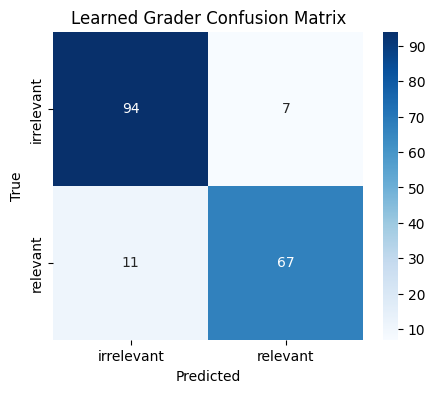

In [ ]:
from langchain_core.documents import Document

grader_gold = _load_jsonl(DATA_DIR / 'grader_gold.jsonl')

def _resolve_saved_model_dir(model_name: str) -> Path:
    """Find a trained model in Drive or local runtime; copy local -> Drive if needed."""
    candidates = [MODEL_DIR / model_name]
    if 'LOCAL_MODEL_DIR' in globals():
        candidates.append(LOCAL_MODEL_DIR / model_name)
    candidates.append(Path('/content/AI574/models') / model_name)

    for candidate in candidates:
        if candidate.exists() and any(candidate.iterdir()):
            if candidate != MODEL_DIR / model_name and (MODEL_DIR / model_name).parent.exists():
                target = MODEL_DIR / model_name
                if not target.exists():
                    shutil.copytree(candidate, target)
                    print(f'Copied {candidate} -> {target}')
                return target
            return candidate

    raise FileNotFoundError(
        f"Could not find trained model '{model_name}'.\n"
        f"Expected Drive path: {MODEL_DIR / model_name}\n"
        f"Run Section 4 / cell 12 first to train and save the grader, then rerun this eval cell."
    )

# Load trained model from disk for clean eval path.
grader_model_dir = _resolve_saved_model_dir('grader_minilm')
print('Loading learned grader from:', grader_model_dir)
learned_grader = CrossEncoder(str(grader_model_dir))
llm_grader = DocumentGrader(llm=llm)

def learned_predict_label(query: str, doc: str, threshold: float = 0.5) -> int:
    score = float(learned_grader.predict([(query, doc)])[0])
    return int(score >= threshold)

# Evaluate learned grader
y_true = [int(r['label']) for r in grader_gold]
y_pred = [learned_predict_label(r['query'], r['document']) for r in grader_gold]

acc = accuracy_score(y_true, y_pred)
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
print({'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1})

# Latency benchmark: learned grader vs DocumentGrader.grade_single
lat_n = min(200, len(grader_gold))
subset = grader_gold[:lat_n]

t0 = time.perf_counter()
_ = [learned_predict_label(x['query'], x['document']) for x in subset]
learned_ms = (time.perf_counter() - t0) * 1000 / max(1, lat_n)

t0 = time.perf_counter()
for x in subset:
    _ = llm_grader.grade_single(x['query'], Document(page_content=x['document'], metadata={}))
llm_ms = (time.perf_counter() - t0) * 1000 / max(1, lat_n)

print({'learned_ms_per_pair': learned_ms, 'llm_ms_per_pair': llm_ms})

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['irrelevant', 'relevant'], yticklabels=['irrelevant', 'relevant'])
plt.title('Learned Grader Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## 7) Evaluation - Router

Side-by-side comparison of:
1. Fine-tuned DistilBERT router
2. LLM-only supervisor router (`SupervisorAgent.route`)

against router gold labels.

,router,accuracy,precision_macro,recall_macro,f1_macro,ms_per_query
0,DistilBERT fine-tuned router,1.000,1.000000,1.0000,1.000000,19.388380
1,LLM-only supervisor router,0.845,0.855282,0.8141,0.795452,1088.574354


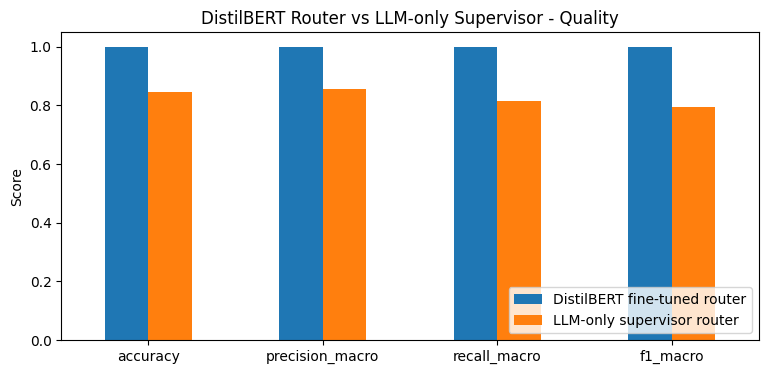

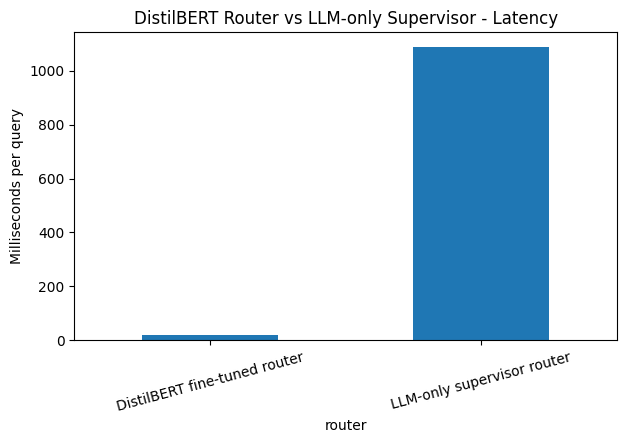

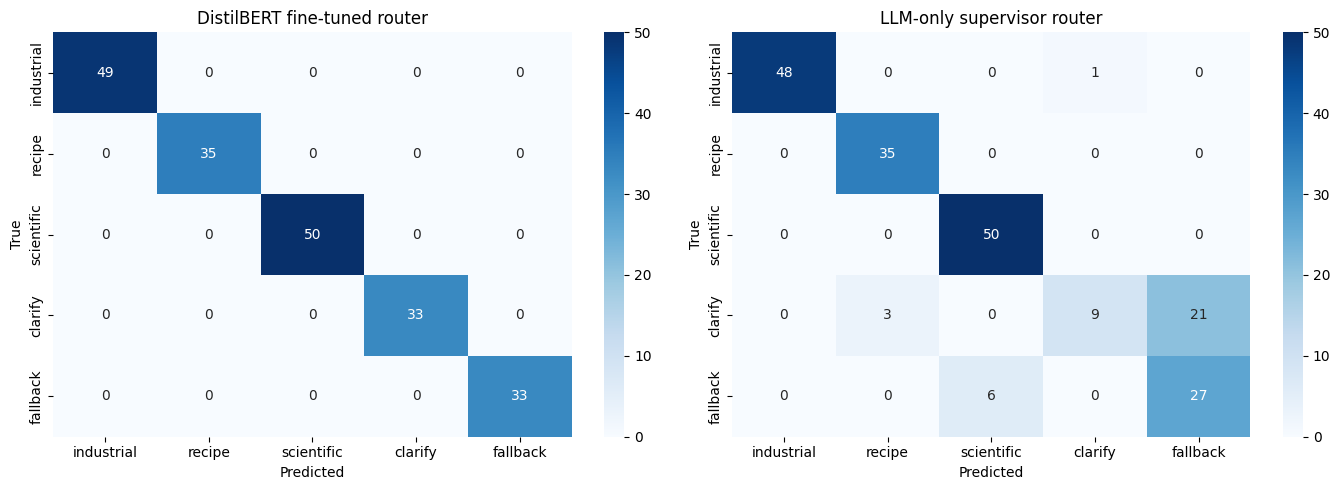

Disagreements: 31 / 200


,query,gold_label,distilbert_pred,llm_only_pred
0,I need help with my mortgage refinancing and a...,clarify,clarify,fallback
1,What are the benefits of regular meditation fo...,clarify,clarify,fallback
2,Find a good geology book,fallback,fallback,scientific
3,I need help with my emergency fund and also wa...,clarify,clarify,fallback
4,Can you recommend a good puzzle video game and...,clarify,clarify,fallback
5,I need a recipe for a hearty vegetarian stew a...,clarify,clarify,recipe
6,I need a recipe for a healthy chicken stir-fry...,clarify,clarify,recipe
7,How to manage stress from political news and w...,clarify,clarify,fallback
8,What's the best way to learn about different t...,clarify,clarify,fallback
9,Can you recommend a good strategy video game a...,clarify,clarify,fallback


In [ ]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

router_gold = _load_jsonl(DATA_DIR / 'router_gold.jsonl')

router_tokenizer = AutoTokenizer.from_pretrained(str(MODEL_DIR / 'router_distilbert'))
router_clf = AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIR / 'router_distilbert'))
router_clf.eval()

supervisor = SupervisorAgent(llm=llm)


def predict_router_distilbert(query: str) -> str:
    inputs = router_tokenizer(query, return_tensors='pt', truncation=True, max_length=128)
    with torch.no_grad():
        logits = router_clf(**inputs).logits
    pred = int(torch.argmax(logits, dim=-1).cpu().numpy()[0])
    return id2label[pred]


def predict_router_llm_only(query: str) -> str:
    out = supervisor.route(query)
    domain = out.get('domain', 'fallback')
    return domain if domain in ROUTER_LABELS else 'fallback'


def evaluate_router(name: str, predict_fn) -> dict:
    t0 = time.perf_counter()
    preds = [predict_fn(row['query']) for row in router_gold]
    ms_per_query = (time.perf_counter() - t0) * 1000 / max(1, len(router_gold))

    y_true = [row['label'] for row in router_gold]
    acc = accuracy_score(y_true, preds)
    p, r, f1, _ = precision_recall_fscore_support(y_true, preds, average='macro', zero_division=0)

    return {
        'router': name,
        'accuracy': acc,
        'precision_macro': p,
        'recall_macro': r,
        'f1_macro': f1,
        'ms_per_query': ms_per_query,
        'preds': preds,
    }


comparison = [
    evaluate_router('DistilBERT fine-tuned router', predict_router_distilbert),
    evaluate_router('LLM-only supervisor router', predict_router_llm_only),
]

metrics_df = pd.DataFrame([
    {k: v for k, v in row.items() if k != 'preds'}
    for row in comparison
])

display(metrics_df)

# Side-by-side metric bars
plot_df = metrics_df.set_index('router')[['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']]
ax = plot_df.T.plot(kind='bar', figsize=(9, 4), ylim=(0, 1.05), rot=0)
ax.set_title('DistilBERT Router vs LLM-only Supervisor - Quality')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.show()

# Side-by-side latency bars
ax = metrics_df.set_index('router')['ms_per_query'].plot(kind='bar', figsize=(7, 4), rot=15)
ax.set_title('DistilBERT Router vs LLM-only Supervisor - Latency')
ax.set_ylabel('Milliseconds per query')
plt.show()

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_true = [row['label'] for row in router_gold]

for ax, row in zip(axes, comparison):
    cm = confusion_matrix(y_true, row['preds'], labels=ROUTER_LABELS)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=ROUTER_LABELS,
        yticklabels=ROUTER_LABELS,
        ax=ax,
    )
    ax.set_title(row['router'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

# Show disagreements between DistilBERT and LLM-only routing.
distilbert_preds = comparison[0]['preds']
llm_preds = comparison[1]['preds']

disagreements = pd.DataFrame([
    {
        'query': row['query'],
        'gold_label': row['label'],
        'distilbert_pred': d_pred,
        'llm_only_pred': l_pred,
    }
    for row, d_pred, l_pred in zip(router_gold, distilbert_preds, llm_preds)
    if d_pred != l_pred
])

print(f'Disagreements: {len(disagreements)} / {len(router_gold)}')
display(disagreements.head(20))

## 8) Opt-in Runtime Adapters

These notebook-local adapters preserve production interfaces and are enabled only when:
- `USE_LEARNED_GRADER=1`
- `USE_LEARNED_ROUTER=1`

In [ ]:
from typing import Optional
from langchain_core.documents import Document
from orchestration.hybrid_router import HybridRoutePrediction

class LearnedDocumentGrader:
    def __init__(self, model_path: Path, threshold: float = 0.5):
        self.model = CrossEncoder(str(model_path))
        self.threshold = threshold

    def grade_documents(self, query: str, documents: List[Document]) -> Dict[str, List[Document]]:
        if not documents:
            return {'relevant': [], 'irrelevant': [], 'ambiguous': [], 'grades': []}

        pairs = [(query, d.page_content[:2000]) for d in documents]
        scores = self.model.predict(pairs)

        buckets = {'relevant': [], 'irrelevant': [], 'ambiguous': []}
        grades = []
        for i, (doc, s) in enumerate(zip(documents, scores)):
            score = float(s)
            relevance = 'relevant' if score >= self.threshold else 'irrelevant'
            buckets[relevance].append(doc)
            grades.append({'doc_index': i, 'grade': {'relevance': relevance, 'score': score, 'reasoning': 'cross-encoder'}})

        return {**buckets, 'grades': grades}


class LearnedDomainClassifier:
    def __init__(self, model_path: Path, label2id: Dict[str, int], min_confidence: float = 0.70, min_margin: float = 0.15):
        self.label2id = label2id
        self.id2label = {v: k for k, v in label2id.items()}
        self.min_confidence = min_confidence
        self.min_margin = min_margin
        self.tokenizer = AutoTokenizer.from_pretrained(str(model_path))
        self.model = AutoModelForSequenceClassification.from_pretrained(str(model_path))
        self.model.eval()

    def predict(self, query: str) -> HybridRoutePrediction:
        inputs = self.tokenizer(query, return_tensors='pt', truncation=True, max_length=128)
        with torch.no_grad():
            logits = self.model(**inputs).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

        top2 = np.argsort(-probs)[:2]
        top_idx, second_idx = int(top2[0]), int(top2[1])
        top_domain = self.id2label[top_idx]
        second_domain = self.id2label[second_idx]
        top_conf = float(probs[top_idx])
        second_conf = float(probs[second_idx])
        margin = top_conf - second_conf

        accepted = (
            top_domain in {'industrial', 'recipe', 'scientific'}
            and top_conf >= self.min_confidence
            and margin >= self.min_margin
        )

        reason = (
            f'Learned classifier predicted {top_domain} '
            f'(confidence={top_conf:.2f}, margin={margin:.2f}).'
        )

        return HybridRoutePrediction(
            domain=top_domain if top_domain in {'industrial', 'recipe', 'scientific'} else 'fallback',
            confidence=top_conf,
            second_domain=second_domain,
            second_confidence=second_conf,
            margin=margin,
            scores={self.id2label[i]: float(probs[i]) for i in range(len(probs))},
            accepted=accepted,
            reason=reason,
        )

In [ ]:
os.environ["USE_LEARNED_GRADER"] = "1"
os.environ["USE_LEARNED_ROUTER"] = "1"

In [ ]:
# Demo wiring: run_query end-to-end with optional adapters
from orchestration import workflow_graph as wg
from rag_core import crag_pipeline as cp
from foundation.model_registry import get_llm
from ingestion.index_builder import IndexBuilder

USE_LEARNED_GRADER = os.getenv('USE_LEARNED_GRADER', '0') == '1'
USE_LEARNED_ROUTER = os.getenv('USE_LEARNED_ROUTER', '0') == '1'

runtime_grader = LearnedDocumentGrader(MODEL_DIR / 'grader_minilm') if USE_LEARNED_GRADER else None
runtime_router = LearnedDomainClassifier(MODEL_DIR / 'router_distilbert', label2id=label2id) if USE_LEARNED_ROUTER else None

print('USE_LEARNED_GRADER =', USE_LEARNED_GRADER)
print('USE_LEARNED_ROUTER =', USE_LEARNED_ROUTER)

orig_supervisor_cls = wg.SupervisorAgent
orig_doc_grader_cls = cp.DocumentGrader

try:
    if USE_LEARNED_ROUTER:
        def _supervisor_factory(llm_obj):
            return orig_supervisor_cls(llm_obj, hybrid_router=runtime_router, enable_hybrid_router=True)
        wg.SupervisorAgent = _supervisor_factory

    if USE_LEARNED_GRADER:
        class _NotebookDocumentGrader:
            def __init__(self, llm_obj):
                self._delegate = runtime_grader
            def grade_documents(self, query, documents):
                return self._delegate.grade_documents(query, documents)
            def grade_single(self, query, document):
                one = self.grade_documents(query, [document])
                if one['relevant']:
                    return {'relevance': 'relevant', 'score': 1.0, 'reasoning': 'learned'}
                return {'relevance': 'irrelevant', 'score': 0.0, 'reasoning': 'learned'}
            def has_sufficient_context(self, grading_result):
                return len(grading_result.get('relevant', [])) >= 1
        cp.DocumentGrader = _NotebookDocumentGrader

    llm_runtime = get_llm(os.getenv('DEFAULT_MODEL_ID', 'gemini_flash'))
    embedder_runtime = EmbeddingService()
    vs_runtime = VectorStoreService(embedding_service=embedder_runtime)
    index_builder_runtime = IndexBuilder(vector_store=vs_runtime)

    wf = wg.build_workflow(llm_runtime, vs_runtime, index_builder_runtime)

    sample_queries = [
        'PowerFlex 525 F004 fault during startup',
        'What can I substitute for eggs in brownies?',
        'Summarize recent RAG papers from arxiv',
        'Is keto evidence-based and can you suggest recipes?',
    ]

    for q in sample_queries:
        out = wg.run_query(wf, q)
        print('\nQ:', q)
        print('Route:', out.get('domain'), '| status:', out.get('status'))
        print('Answer preview:', str(out.get('response', ''))[:180])
finally:
    wg.SupervisorAgent = orig_supervisor_cls
    cp.DocumentGrader = orig_doc_grader_cls

USE_LEARNED_GRADER = True
USE_LEARNED_ROUTER = True

Q: PowerFlex 525 F004 fault during startup
Route: industrial | status: complete
Answer preview: You are experiencing a Fault Code F004, which indicates an Undervoltage condition on your Allen-Bradley PowerFlex 525 VFD. This means the DC bus voltage has dropped below its trip 



Q: What can I substitute for eggs in brownies?
Route: recipe | status: complete
Answer preview: Based on the provided recipes, here are some options for substituting eggs in brownies:

1.  **Flour and Water Paste:**
    *   **Recipe:** "no egg brownies" (Document 1)
    *   *

Q: Summarize recent RAG papers from arxiv
Route: scientific | status: complete
Answer preview: **Summary of Retrieved RAG Paper**

**Objective**
The paper introduces Citegeist, an application pipeline designed to address the challenges of Large Language Models (LLMs) halluci

Q: Is keto evidence-based and can you suggest recipes?
Route: clarify | status: complete
Answer preview: To clarify, are you looking for information on the scientific evidence for keto, or are you mainly interested in recipe suggestions?


## 9) Methodology Summary

### Objective

Reduce runtime LLM calls in two expensive path segments while preserving behavior:
- Document relevance grading in CRAG
- Domain routing before specialist-agent selection

### Experimental Design

- Baseline grader: existing `DocumentGrader` (LLM-as-judge)
- Candidate grader: `cross-encoder/ms-marco-MiniLM-L-6-v2`
- Baseline router: LLM-only supervisor routing
- Candidate router: `distilbert-base-uncased` 5-class classifier

### Data

- Silver labels distilled using Gemini 2.5 Flash.
- Grader data fields: `query`, `document`, `label`, `domain`, `kind`.
- Router data fields: `query`, `label`.
- Gold splits are held out before training for unbiased comparisons.

### Risks and mitigations

- Label noise from distillation -> keep held-out gold slices and inspect confusion matrices.
- Class imbalance in routing -> stratified splits and macro metrics.
- Shortcut learning in grader -> include hard negatives and cross-domain negatives.

## 10) Results Table Template

Fill this after you execute all training/eval cells.

| Component | Baseline | Fine-tuned | Delta |
|---|---:|---:|---:|
| Grader Accuracy |  |  |  |
| Grader F1 (relevant) |  |  |  |
| Grader ms/pair |  |  |  |
| Router Accuracy |  |  |  |
| Router Macro-F1 |  |  |  |
| Router ms/query |  |  |  |
| LLM Supervisor Escalation Rate |  |  |  |

Use this table in the report appendix and keep raw outputs in notebook cells above.

## 11) Failure Modes and Recommended Thresholds

### Expected failure modes

- **Grader false positives:** semantically similar but non-answering chunks marked relevant.
- **Grader false negatives:** short technical snippets with sparse lexical overlap.
- **Router confusion:** `scientific` vs `fallback` for broad current-events science prompts.
- **Router over-confidence:** unclear cross-domain prompts should be `clarify`, not hard-routed.

### Initial thresholds to test

- Learned grader relevance threshold: `0.50`, then sweep `[0.45, 0.55, 0.60]`.
- Learned router confidence threshold: `0.70`.
- Learned router margin threshold: `0.15`.

### Production hardening recommendations

1. Re-distill monthly from recent user queries and accepted responses.
2. Add drift checks on label distribution and confidence calibration.
3. Keep LLM supervisor as safe fallback for low-confidence learned predictions.
4. Keep adversarial out-of-domain probes in the router regression suite.